# Evaluate Model Performance on single station

This code reads test events on which the model has been applied and makes plots based on output probabilities. The plots refer to proton events and protons SMONLY events to garantee a significant muon component. The plots shown are : Inverse cumulative distribution function (1 - cdf), probabity distribution function (pdf) and feature importance values of the model. Here all individual events are read and stations probabilities are put in a single list to show single stations performance. 

- Please save both in .png and .pdf format using a (7,6) or (16,9) aspect ratio.

# Imports

In [1]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath,amssymb}"
plt.style.use('plots.mplstyle')
import warnings
from py_code.models import XGBoost_IC_test_model
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch
from pathlib import Path
from py_code import config_loader 
from py_code import model_performance as mp

# Create directories and parent directories

In [2]:
conf = config_loader.load_config("config.yaml")
DAT_path_protons = conf["DAT_path_protons"]
DAT_path_gammas = conf["DAT_path_gammas"]

TRAIN_DAT_MIN = conf["TRAIN_DAT_MIN"]
TRAIN_DAT_MAX = conf["TRAIN_DAT_MAX"]

TEST_PROTONS_DAT_MIN = conf["TEST_PROTONS_DAT_MIN"]
TEST_PROTONS_DAT_MAX = conf["TEST_PROTONS_DAT_MAX"]

TEST_GAMMAS_DAT_MIN = conf["TEST_GAMMAS_DAT_MIN"]
TEST_GAMMAS_DAT_MAX = conf["TEST_GAMMAS_DAT_MAX"]

traces_dir = conf["traces_dir"]
feats_dir =  conf["feats_dir"]
output_dir = conf["output_dir"]
models_dir = conf["models_dir"]
results_dir = conf["results_dir"]
pictures_dir = conf["pictures_dir"]

params_dir = conf["params_dir"]
cut_dir = conf["cut_dir"]
ADC_dir = conf["ADC_dir"]
array_dir = conf["array_dir"]

features_cut_dir = conf["features_cut_dir"]
training_selection_dir = conf["training_selection_dir"]
testing_selection_dir = conf["testing_selection_dir"]

tank_type = conf["tank_type"]
FF = conf["FF"]
time_window = conf["time_window"]
min_energy_reco = conf["min_energy_reco"]
max_energy_reco = conf["max_energy_reco"]
min_theta = conf["min_theta"]
max_theta = conf["max_theta"]
intended_cut_on_pes = conf["intended_cut_on_pes"]
mpmt_or_8inches = conf["mpmt_or_8inches"]
ADC_MHz = conf["ADC_MHz"]

train_min_st_dist = conf["train_min_st_dist"]
train_max_st_dist = conf["train_max_st_dist"]
train_pe_min = conf["train_pe_min"]

test_min_st_dist = conf["test_min_st_dist"]
test_max_st_dist = conf["test_max_st_dist"]
test_pe_min = conf["test_pe_min"]

In [3]:
PROJECT_DIR = Path.cwd().parent

In [4]:
# Specify model and label as well as feature directory FOR FEATURES IMPORTANCE PLOTS
feat_imp_save_path = Path(f"{PROJECT_DIR}/{models_dir}/{array_dir}/{params_dir}/{features_cut_dir}/{training_selection_dir}/")
label = f"{params_dir}_{features_cut_dir}_{training_selection_dir}"

# Specify proton txt directory
PROTONS_txt_dir = Path(f"{PROJECT_DIR}/{output_dir}/{array_dir}/test_protons/{params_dir}/{features_cut_dir}/{testing_selection_dir}/")
SMONLY_txt_dir = Path(f"{PROJECT_DIR}/{output_dir}/{array_dir}/test_protons_SMONLY/{params_dir}/{features_cut_dir}/{testing_selection_dir}/")

pictures_save_dir = Path(f"{PROJECT_DIR}/{pictures_dir}/{array_dir}/{params_dir}/{training_selection_dir}/{testing_selection_dir}/") 

pictures_save_dir.mkdir(parents=True, exist_ok = True)

In [5]:
proton_station_data = mp.get_all_stations(PROTONS_txt_dir)
y_test = proton_station_data.y
p_test = proton_station_data.probabilities

smonly_station_data = mp.get_all_stations(SMONLY_txt_dir)
y_test_sm = smonly_station_data.y
p_test_sm = smonly_station_data.probabilities

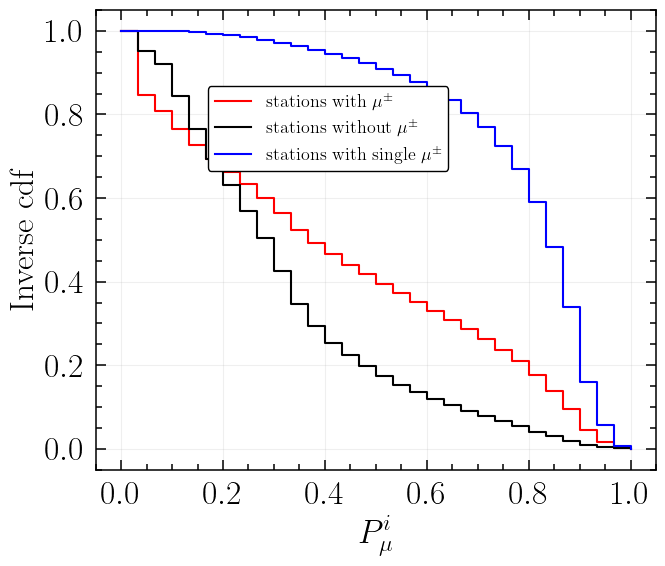

In [6]:
# Call the function in test .py to make the inverse cumulative

bins = 30

x_s, icdf_s = mp.binned_inv_cdf(p_test[y_test == 1], bins=bins)
x_b, icdf_b = mp.binned_inv_cdf(p_test[y_test == 0], bins=bins)
x_SM, icdf_SM = mp.binned_inv_cdf(p_test_sm[y_test_sm == 1], bins=bins)


u = np.linspace(0, 1, len(icdf_s), endpoint=True)
u_SM = np.linspace(0, 1, len(icdf_SM), endpoint=True)

du = u[1] - u[0]
du_SM = u_SM[1] - u_SM[0]

pdf_s = du / np.diff(icdf_s, append=icdf_s[-1])
pdf_b = du / np.diff(icdf_b, append=icdf_b[-1])

pdf_s = np.clip(pdf_s, 0, np.inf)
pdf_b = np.clip(pdf_b, 0, np.inf)

plt.figure(figsize=(7, 6))

plt.step(u, icdf_s, where="post", lw=1.5, color="red", label=r"stations with $\mu^{\pm}$")
plt.step(u, icdf_b, where="post", lw=1.5, color="black", label=r"stations without $\mu^{\pm}$")
plt.step(u_SM, icdf_SM, where="post", lw=1.5, color="BLUE", label=r"stations with single $\mu^{\pm}$")


plt.xlabel("$P_{\mu}^{i}$", fontsize = 24)
plt.ylabel("Inverse cdf", fontsize = 24)
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize = 24)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize = 24)
plt.xlim(-0.05, 1.05)

plt.legend(frameon=True, fontsize=13, loc=(0.20,0.65), facecolor="white", framealpha=1, edgecolor = "black")
plt.grid(True, alpha=0.2)

plt.tight_layout()

plt.savefig(pictures_save_dir / "inverse_cumulative.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "inverse_cumulative.png", dpi=600, bbox_inches="tight")

plt.show()

Number of true muons stations =  225135
Number of non-muons stations =  969315
Number of single muons stations =  52402


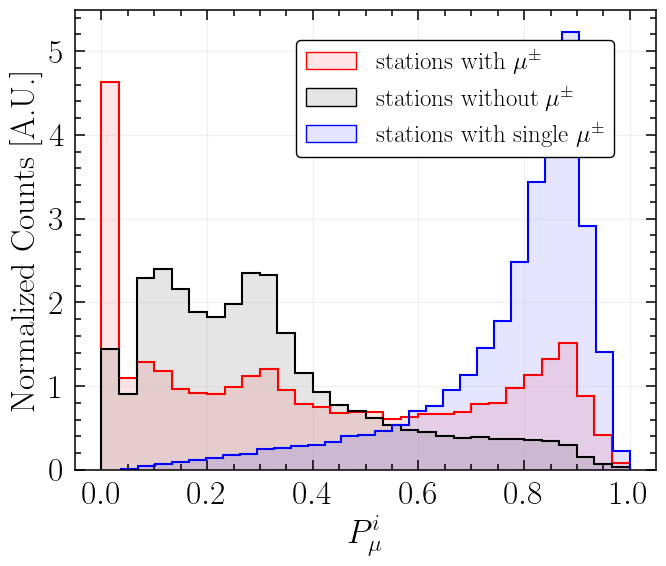

In [7]:
# Plot the probabilities 

bins = 30
plt.figure(figsize=(7, 6))

plt.hist(p_test[y_test == 1],bins=bins, density=True,histtype="stepfilled", color="red", alpha=0.1)
plt.hist(p_test[y_test == 1],bins=bins, density=True,histtype="step", color="red", lw=1.5)
plt.hist(p_test[y_test == 0],bins=bins, density=True,histtype="stepfilled", color="black", alpha=0.1)
plt.hist(p_test[y_test == 0],bins=bins, density=True,histtype="step", color="black", lw=1.5)
plt.hist(p_test_sm[y_test_sm == 1],bins=bins, density=True,histtype="stepfilled", color="blue", alpha=0.1)
plt.hist(p_test_sm[y_test_sm == 1],bins=bins, density=True,histtype="step", color="blue", lw=1.5)

print("Number of true muons stations = ", len(y_test[y_test == 1]))
print("Number of non-muons stations = ", len(y_test[y_test == 0]))
print("Number of single muons stations = ", len(y_test_sm[y_test_sm == 1]))

 
handles = [
    Patch(facecolor=(1,0,0,0.1), edgecolor=(1,0,0,1), linewidth=1, label=r"stations with $\mu^{\pm}$"),
    Patch(facecolor=(0,0,0,0.1), edgecolor=(0,0,0,1), linewidth=1, label=r"stations without $\mu^{\pm}$"),
    Patch(facecolor=(0,0,1,0.1), edgecolor=(0,0,1,1), linewidth=1, label=r"stations with single $\mu^{\pm}$")]


plt.xlabel("$P_{\mu}^{i}$", fontsize = 24)
plt.ylabel("Normalized Counts [A.U.]", fontsize = 24)
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize = 24)
plt.yticks(fontsize = 24)

plt.legend(handles = handles, frameon=True, fontsize=18, facecolor="white", edgecolor = "black", framealpha=1, loc=(0.38,0.68))
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.savefig(pictures_save_dir / "probs_distribution.pdf", dpi = 600, bbox_inches = "tight")
plt.savefig(pictures_save_dir / "probs_distribution.png", dpi = 600, bbox_inches = "tight")

plt.show()

In [8]:
feature_importance_data = mp.get_feature_importance(feat_imp_save_path / f"feature_importance_{label}.txt")

imp_feat = feature_importance_data.features
imp_vals = feature_importance_data.values
imp_feat, imp_vals = mp.get_feature_importance(feat_imp_save_path / f"feature_importance_{label}.txt")
idx = np.argsort(imp_vals)

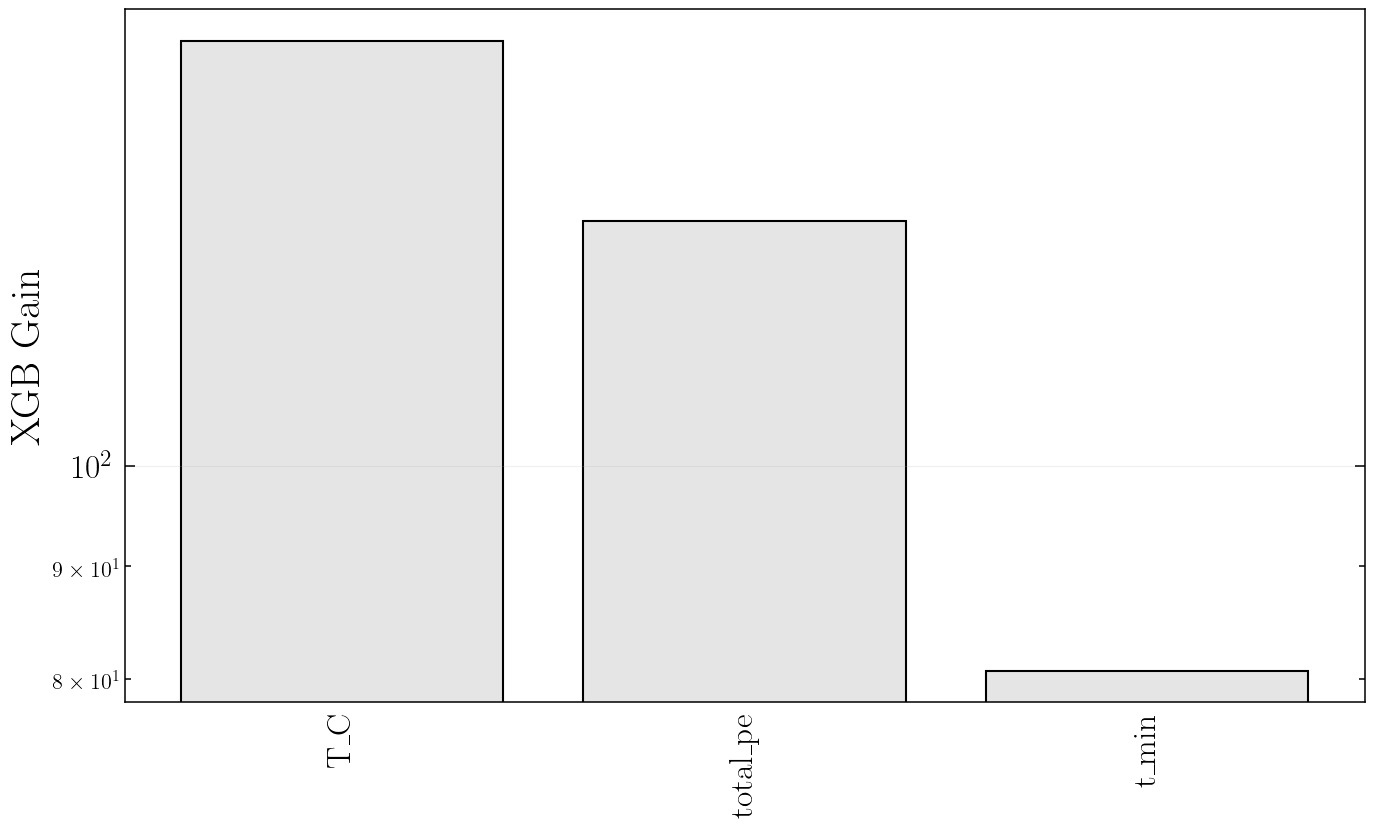

In [9]:
plt.figure(figsize=(16, 9))

plt.bar(imp_feat[idx], imp_vals[idx], color="black", alpha=0.1)
plt.bar(imp_feat[idx], imp_vals[idx], facecolor='none', edgecolor='black', linewidth=1.5)

plt.ylabel("XGB Gain", fontsize=30)

plt.tick_params(axis='x', which='both', bottom=False, top=False, left=False, right=False)

plt.xticks(rotation = 90, fontsize = 24)
plt.yticks(fontsize = 24)

plt.yscale("log")
plt.gca().invert_xaxis()  

plt.grid(True, axis='y', alpha=0.2)

plt.savefig(pictures_save_dir / "features_importance.pdf", dpi = 600, bbox_inches = "tight")
plt.savefig(pictures_save_dir / "features_importance.png", dpi = 600, bbox_inches = "tight")

plt.show()

In [10]:
station_roc_results = mp.get_station_ROC(p_test=p_test, y_test=y_test, p_test_sm=p_test_sm, y_test_sm=y_test_sm)

p_mu = station_roc_results.p_mu
p_bkg = station_roc_results.p_bkg
p_mu_sm = station_roc_results.p_mu_sm
fpr = station_roc_results.fpr
tpr = station_roc_results.tpr
thresholds = station_roc_results.thresholds
auc = station_roc_results.auc
fpr_smonly = station_roc_results.fpr_smonly
tpr_smonly = station_roc_results.tpr_smonly
thresholds_smonly = station_roc_results.thresholds_smonly
auc_smonly = station_roc_results.auc_smonly

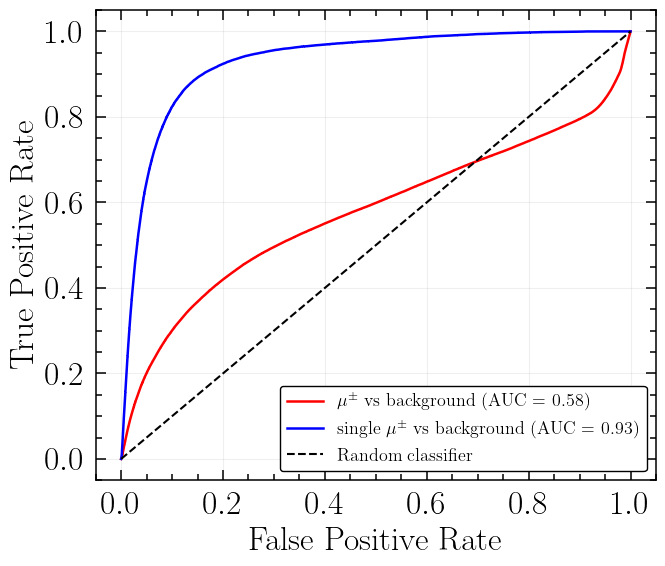

In [11]:
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, color="red", lw=1.8, label=rf"$\mu^{{\pm}}$ vs background (AUC = {auc:.2f})")
plt.plot(fpr_smonly, tpr_smonly, color="blue", lw=1.8, label=rf"single $\mu^{{\pm}}$ vs background (AUC = {auc_smonly:.2f})")
plt.plot([0, 1], [0, 1], color="black", lw=1.5, ls="--", label="Random classifier")

plt.xlabel("False Positive Rate", fontsize=24)
plt.ylabel("True Positive Rate", fontsize=24)

plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=24)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=24)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.legend(frameon=True, fontsize=13, loc="lower right", facecolor="white", framealpha=1, edgecolor="black")

plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.savefig(pictures_save_dir / "roc_curve.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "roc_curve.png", dpi=600, bbox_inches="tight")

plt.show()

In [12]:
station_pr_results = mp.get_station_PR(p_mu=station_roc_results.p_mu, p_bkg=station_roc_results.p_bkg, p_mu_sm=station_roc_results.p_mu_sm)
precision = station_pr_results.precision
recall = station_pr_results.recall
thresholds_pr = station_pr_results.thresholds
pr_auc = station_pr_results.pr_auc
baseline = station_pr_results.baseline
precision_smonly = station_pr_results.precision_smonly
recall_smonly = station_pr_results.recall_smonly
thresholds_pr_smonly = station_pr_results.thresholds_smonly
pr_auc_smonly = station_pr_results.pr_auc_smonly
baseline_smonly = station_pr_results.baseline_smonly

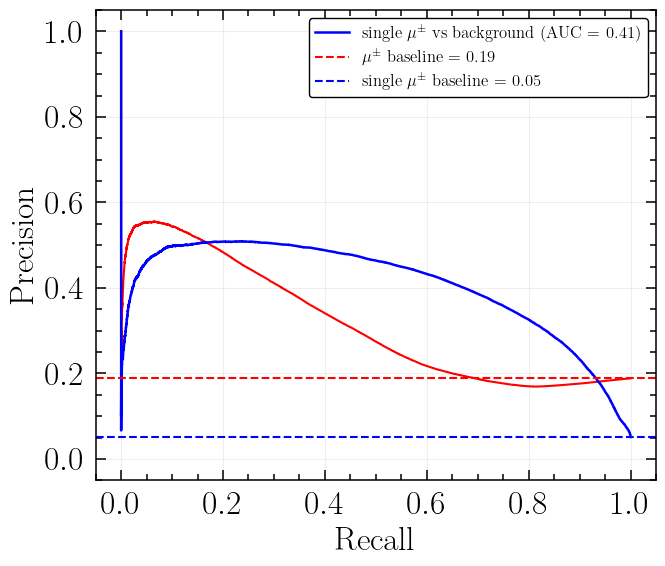

In [13]:
step = 5
idx = np.unique(np.r_[np.arange(0, len(recall), step), len(recall) - 1])
idx_SM = np.unique(np.r_[np.arange(0, len(recall_smonly), step), len(recall_smonly) - 1])

plt.figure(figsize=(7, 6))

plt.plot(recall[idx], precision[idx], lw=1.5, color = "red")
plt.plot(recall_smonly[idx_SM], precision_smonly[idx_SM], color="blue", lw=1.8, label=rf"single $\mu^{{\pm}}$ vs background (AUC = {pr_auc_smonly:.2f})")
plt.axhline(baseline, color="red", lw=1.5, ls="--", label=rf"$\mu^{{\pm}}$ baseline = {baseline:.2f}")
plt.axhline(baseline_smonly, color="blue", lw=1.5, ls="--", label=rf"single $\mu^{{\pm}}$ baseline = {baseline_smonly:.2f}")

plt.xlabel("Recall", fontsize=24)
plt.ylabel("Precision", fontsize=24)

plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=24)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=24)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.legend(frameon=True, fontsize=12, loc="upper right", facecolor="white", framealpha=1, edgecolor="black")
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.savefig(pictures_save_dir / "precision_recall_curve.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "precision_recall_curve.png", dpi=600, bbox_inches="tight")

plt.show()